<h1 style="color: navy; font-weight: bold;">Analiza i predykcja wizyt "no-show" w opiece zdrowotnej</h1>

<h3 style="color: navy; font-weight: bold;">Opis projektu:</h3>

##### Celem projektu jest zrozumienie przyczyn niepojawiania się pacjentów na umówionych wizytach oraz zbudowanie modelu predykcyjnego, który będzie oceniał szansę pojawienia się pacjenta na wizycie, co pozwoli placówkom medycznym lepiej planować grafik wizyt.
##### W analizie wykorzystujemy trzy niezależne źródła danych, aby sprawdzić wpływ demografii, warunków pogodowych oraz uroczystości na obecność pacjentów na umówionych wizytach.

In [34]:
# Import potrzebnych bibliotek

# Manipulacja i analiza danych 
import pandas as pd               # Podstawowa biblioteka do pracy z DataFrames
import numpy as np                # Biblioteka do operacji macierzowych i obliczeń matematycznych

# Wizualizacja danych
import matplotlib.pyplot as plt   # Podstawowe narzędzie do tworzenia wykresów
import seaborn as sns             # Biblioteka budujaca estetyczne wykresy statystyczne

# Metody statystyczne
from scipy.stats import chi2_contingency
from scipy import stats

# Manipulacja czasem
from datetime import timedelta

# Budowa lasu losowego
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

<h3 style="color: navy; font-weight: bold;">1. Wczytanie danych:</h3>

In [2]:
# Wczytanie danych
df_appointments = pd.read_csv("noshow_appointments.csv")
df_weather = pd.read_csv("weather.csv", encoding="ISO-8859-1") # plik z danymi jest w języku portugalskim, dodajemy encoding do prawidłowego odczytu

In [3]:
# Tworzymy Dataset z datami świat w Vitori w Brazylii w 2016 roku między kwietniem, a czerwcem
holidays_dates_2016 = ["2016-05-01", # Święto Pracy
                 "2016-05-23",       # Kolonizacja Stanu Espírito Santo
                 "2016-05-26",       # Boże Ciało 
                 "2016-05-27"]       # Dzień pomostowy

df_holidays_dates_2016 = pd.DataFrame({"Holiday Date" : pd.to_datetime(holidays_dates_2016).date,
                                      "Is_Holiday" : 1})

<h3 style="color: navy; font-weight: bold;">2. Czyszczenie danych:</h3>

In [4]:
# Krok 3: Data cleaning
# Wybieranie tylko interesujacych nas kolumn

df_appointments = df_appointments[['PatientId','Gender','AppointmentDay', 'Age', 'Neighbourhood', 'Diabetes', 'Handcap', 'SMS_received', 'No-show', 'ScheduledDay']]
df_weather = df_weather[['Estado', 'ano','mes', 'dia', 'PRECIPITAÇÃO', 'TEMPERATURA.BULBO.SECO', 'UMIDADE', 'VENTO.RAJADA']]

df_appointments.head(5)

,PatientId,Gender,AppointmentDay,Age,Neighbourhood,Diabetes,Handcap,SMS_received,No-show,ScheduledDay
0,2.987250e+13,F,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,0,0,No,2016-04-29T18:38:08Z
1,5.589978e+14,M,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,No,2016-04-29T16:08:27Z
2,4.262962e+12,F,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,No,2016-04-29T16:19:04Z
3,8.679512e+11,F,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,No,2016-04-29T17:29:31Z
4,8.841186e+12,F,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,1,0,0,No,2016-04-29T16:07:23Z


In [5]:
# Zmiana nazw kolumn by język był spójny
new_names = {'Estado': 'State',
             'ano' : 'Year',
             'mes' : 'Month',
             'dia' : 'Day',
             'PRECIPITAÇÃO' : 'Precipitation',
             'TEMPERATURA.BULBO.SECO' : 'Temperature',
             'UMIDADE' : 'Humidity',
             'VENTO.RAJADA' : 'Wind gusts'}
df_weather = df_weather.rename(columns = new_names)

In [6]:
# Wybieranie tylko stanu Espírito Santo (ES) oraz roku 2016
df_weather = df_weather[(df_weather['State']== 'ES') & (df_weather['Year']== 2016) & (df_weather['Month'].isin([4, 5, 6]))]
df_weather.head(5)

,State,Year,Month,Day,Precipitation,Temperature,Humidity,Wind gusts
18124980,ES,2016,4,1,0.0,23.8,95,1.5
18124981,ES,2016,4,1,0.0,24.7,94,2.1
18124982,ES,2016,4,1,0.0,27.0,65,2.1
18124983,ES,2016,4,1,0.0,29.2,56,3.7
18124984,ES,2016,4,1,0.0,30.5,49,3.8


In [7]:
# Agregacja danych pogodowych: grupujemy po roku, miesiacu i dniu, aby uzyskać po jednym wierszu na dobę
df_weather_daily = df_weather.groupby(["Year", "Month", "Day"]).agg({
    "Precipitation" : "sum",
    "Temperature": "mean",
    "Humidity" : "mean",
    "Wind gusts" : "max"
}).reset_index()        # Przekształcenie indeksu w zwykłe kolumny, co umożliwi stworzenie pełnej daty i wykonanie operacji merge

df_weather_daily.head(5)

,Year,Month,Day,Precipitation,Temperature,Humidity,Wind gusts
0,2016,4,1,1.4,28.537209,66.651163,10.0
1,2016,4,2,0.0,28.978082,64.698630,9.2
2,2016,4,3,0.0,29.240244,64.768293,11.1
3,2016,4,4,3.0,29.041667,64.928571,10.6
4,2016,4,5,32.2,26.475294,72.729412,10.1


In [8]:
# Zmiana formatu daty
df_appointments["AppointmentDay"] = pd.to_datetime(df_appointments["AppointmentDay"]).dt.date
df_appointments["ScheduledDay"] = pd.to_datetime(df_appointments["ScheduledDay"]).dt.date
df_appointments.head(2)

,PatientId,Gender,AppointmentDay,Age,Neighbourhood,Diabetes,Handcap,SMS_received,No-show,ScheduledDay
0,2.987250e+13,F,2016-04-29,62,JARDIM DA PENHA,0,0,0,No,2016-04-29
1,5.589978e+14,M,2016-04-29,56,JARDIM DA PENHA,0,0,0,No,2016-04-29


In [9]:
# Tworzenie kolumny z data w tabeli z danymi pogodowymi 
df_weather_daily["Date"] = pd.to_datetime(df_weather_daily[["Year", "Month", "Day"]]).dt.date

In [10]:
# Usuwamy osobne kolumny "Year", "Month", "Date"
df_weather_daily = df_weather_daily.drop(columns = ["Year", "Month", "Day"])
df_weather_daily.head(2)

,Precipitation,Temperature,Humidity,Wind gusts,Date
0,1.4,28.537209,66.651163,10.0,2016-04-01
1,0.0,28.978082,64.698630,9.2,2016-04-02


In [11]:
# Łaczymy tabele
df_merged = df_appointments.merge(
    df_weather_daily,
    left_on = "AppointmentDay",
    right_on = "Date",
    how = "left").merge(
    df_holidays_dates_2016,
    left_on = "AppointmentDay",
    right_on = "Holiday Date",
    how = "left")

# Usuwamy kolumny dat, nie sa nam już potrzebne
df_merged = df_merged.drop(columns = ['Date', 'Holiday Date'])

# Jeśli danego dnia nie ma święta wstawiamy wartość "0"
df_merged["Is_Holiday"] = df_merged["Is_Holiday"].fillna(0).astype(int)     # wypełniamy "0" miejsca NaN, 0 jako int, nie str
df_merged.head(5)

,PatientId,Gender,AppointmentDay,Age,Neighbourhood,Diabetes,Handcap,SMS_received,No-show,ScheduledDay,Precipitation,Temperature,Humidity,Wind gusts,Is_Holiday
0,2.987250e+13,F,2016-04-29,62,JARDIM DA PENHA,0,0,0,No,2016-04-29,10.2,21.80119,80.166667,10.3,0
1,5.589978e+14,M,2016-04-29,56,JARDIM DA PENHA,0,0,0,No,2016-04-29,10.2,21.80119,80.166667,10.3,0
2,4.262962e+12,F,2016-04-29,62,MATA DA PRAIA,0,0,0,No,2016-04-29,10.2,21.80119,80.166667,10.3,0
3,8.679512e+11,F,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,No,2016-04-29,10.2,21.80119,80.166667,10.3,0
4,8.841186e+12,F,2016-04-29,56,JARDIM DA PENHA,1,0,0,No,2016-04-29,10.2,21.80119,80.166667,10.3,0


In [12]:
df_merged.tail(5)

,PatientId,Gender,AppointmentDay,Age,Neighbourhood,Diabetes,Handcap,SMS_received,No-show,ScheduledDay,Precipitation,Temperature,Humidity,Wind gusts,Is_Holiday
110522,2.572134e+12,F,2016-06-07,56,MARIA ORTIZ,0,0,1,No,2016-05-03,0.0,25.708642,68.740741,11.3,0
110523,3.596266e+12,F,2016-06-07,51,MARIA ORTIZ,0,0,1,No,2016-05-03,0.0,25.708642,68.740741,11.3,0
110524,1.557663e+13,F,2016-06-07,21,MARIA ORTIZ,0,0,1,No,2016-04-27,0.0,25.708642,68.740741,11.3,0
110525,9.213493e+13,F,2016-06-07,38,MARIA ORTIZ,0,0,1,No,2016-04-27,0.0,25.708642,68.740741,11.3,0
110526,3.775115e+14,F,2016-06-07,54,MARIA ORTIZ,0,0,1,No,2016-04-27,0.0,25.708642,68.740741,11.3,0


In [13]:
# sprawdzamy czy mamy gdzieś brakujace wartości
df_merged.isnull().sum()

PatientId         0
Gender            0
AppointmentDay    0
Age               0
Neighbourhood     0
Diabetes          0
Handcap           0
SMS_received      0
No-show           0
ScheduledDay      0
Precipitation     0
Temperature       0
Humidity          0
Wind gusts        0
Is_Holiday        0
dtype: int64

In [14]:
# brak brakujacych wartości

In [15]:
# Usuwamy błędy logiczne jeśli się pojawiaja
print(f"Liczba rekordów z wiekiem poniżej 0: {len(df_merged[df_merged['Age'] < 0])}")

Liczba rekordów z wiekiem poniżej 0: 1


In [16]:
df_merged = df_merged[df_merged['Age']>= 0]
print(f"Liczba rekordów z wiekiem poniżej 0: {len(df_merged[df_merged['Age'] < 0])}")

Liczba rekordów z wiekiem poniżej 0: 0


In [17]:
# Zamiana wartości w kolumnie "No-show": No -> 0, Yes -> 1
df_merged["No-show"] = df_merged["No-show"].map({"No" : 0, "Yes" : 1})
df_merged.head(5)

,PatientId,Gender,AppointmentDay,Age,Neighbourhood,Diabetes,Handcap,SMS_received,No-show,ScheduledDay,Precipitation,Temperature,Humidity,Wind gusts,Is_Holiday
0,2.987250e+13,F,2016-04-29,62,JARDIM DA PENHA,0,0,0,0,2016-04-29,10.2,21.80119,80.166667,10.3,0
1,5.589978e+14,M,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,2016-04-29,10.2,21.80119,80.166667,10.3,0
2,4.262962e+12,F,2016-04-29,62,MATA DA PRAIA,0,0,0,0,2016-04-29,10.2,21.80119,80.166667,10.3,0
3,8.679512e+11,F,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,2016-04-29,10.2,21.80119,80.166667,10.3,0
4,8.841186e+12,F,2016-04-29,56,JARDIM DA PENHA,1,0,0,0,2016-04-29,10.2,21.80119,80.166667,10.3,0


In [18]:
# Na koniec Data Cleaningu sprawdzamy nasze dane
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110526 non-null  float64
 1   Gender          110526 non-null  object 
 2   AppointmentDay  110526 non-null  object 
 3   Age             110526 non-null  int64  
 4   Neighbourhood   110526 non-null  object 
 5   Diabetes        110526 non-null  int64  
 6   Handcap         110526 non-null  int64  
 7   SMS_received    110526 non-null  int64  
 8   No-show         110526 non-null  int64  
 9   ScheduledDay    110526 non-null  object 
 10  Precipitation   110526 non-null  float64
 11  Temperature     110526 non-null  float64
 12  Humidity        110526 non-null  float64
 13  Wind gusts      110526 non-null  float64
 14  Is_Holiday      110526 non-null  int64  
dtypes: float64(5), int64(6), object(4)
memory usage: 13.5+ MB


<h3 style="color: navy; font-weight: bold;">Podsumowanie czyszczenia danych:</h3>

#### Zaczęliśmy od surowego zbioru wizyt lekarskich, który wzbogaciliśmy o dane dotyczace pogody oraz uroczystości państwowych i kościelnych.

#### W ramach porzadków:
##### - Wybraliśmy tylko kluczowe kolumny i ujednoliciliśmy ich nazewnictwo
##### - Zmieniliśmy formaty dat, co pozwoliło na poprawne połaczenie trzech źródeł w jedna tabelę
##### - Usunęliśmy błędy logiczne, takie jak ujemny wiek pacjenta
##### - Zakodowaliśmy dane tekstowe na liczbowe (wyniki 'No-show'), przygotowując zbiór pod model uczenia maszynowego.
#### Wynikiem tego jest czysty i kompletny zbiór danych, w którym każda kolumna gotowa jest do analizy statystycznej i modelowania.

<h3 style="color: navy; font-weight: bold;">3. Wizualizacja danych:</h3>

In [19]:
df_merged.head(2)

,PatientId,Gender,AppointmentDay,Age,Neighbourhood,Diabetes,Handcap,SMS_received,No-show,ScheduledDay,Precipitation,Temperature,Humidity,Wind gusts,Is_Holiday
0,2.987250e+13,F,2016-04-29,62,JARDIM DA PENHA,0,0,0,0,2016-04-29,10.2,21.80119,80.166667,10.3,0
1,5.589978e+14,M,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,2016-04-29,10.2,21.80119,80.166667,10.3,0


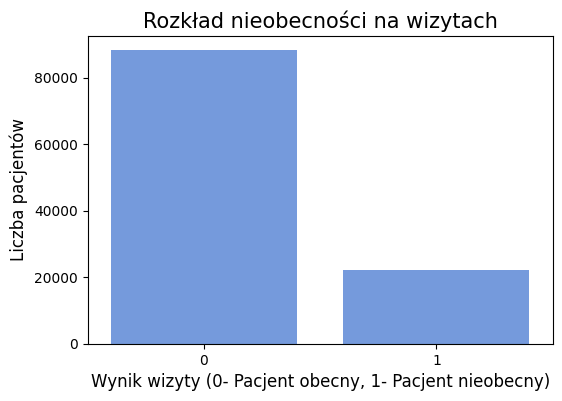

In [20]:
# 1: Wykres "Rozkład nieobecności na wizytach": 
# Ustawiamy wymiary wykresu
plt.figure(figsize=(6, 4))

# Tworzymy wykres słupkowy
w1 = sns.countplot(data = df_merged, x = "No-show", color = "cornflowerblue")

# Dodajemy tytuł i opisy osi
plt.title("Rozkład nieobecności na wizytach", fontsize = 15)
plt.ylabel("Liczba pacjentów", fontsize = 12)
plt.xlabel("Wynik wizyty (0- Pacjent obecny, 1- Pacjent nieobecny)", fontsize = 12)
plt.show()

<h4 style="color: navy; font-weight: bold;">Wniosek 1: </h4> <h5 style="color: navy;">Większość pacjentów stawia się na wizyty, ale 20 procentowa skala nieobecności jest istotnym problemem operacyjnym dla placówek.</h5>

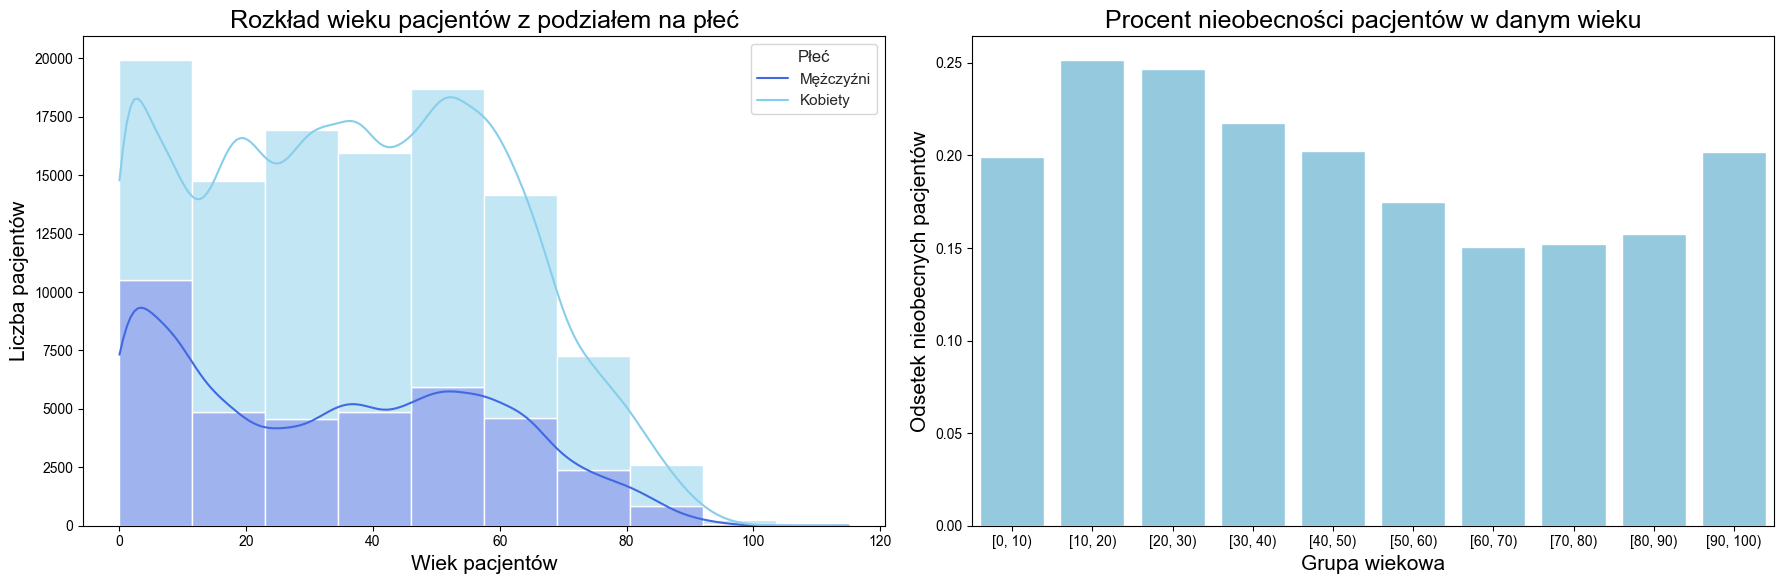

In [21]:
# 2 i 3: Wykres "Rozkład wieku pacjentów z podziałem na płeć" oraz "Procent nieobecności pacjentów w danym wieku" : 
# Tworzymy grupy wiekowe co 10 lat
df_merged["Age_Group"] = pd.cut(df_merged["Age"], bins = range(0, 101, 10), right = False) # przedziały lewostronnie domknięte

# Tworzymy ramkę na dwa wykresy:
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # 1 wiersz, 2 kolumny
sns.set_theme(style="whitegrid")

# Histogram
sns.histplot(data = df_merged,
             x = "Age",
             bins = 10,
             kde = True,
             ax = axes[0],
             hue = "Gender",
             multiple="stack",  # podzielenie słupków
             palette= ['skyblue', 'royalblue'])

axes[0].set_title("Rozkład wieku pacjentów z podziałem na płeć", fontsize = 18)
axes[0].set_xlabel("Wiek pacjentów", fontsize = 15)
axes[0].set_ylabel("Liczba pacjentów", fontsize = 15)
axes[0].legend(title='Płeć', labels=['Mężczyźni', 'Kobiety'])

# Barplot
sns.barplot(data = df_merged,
            x = "Age_Group",
            y = "No-show",
            ax = axes[1],
            color = "skyblue",
            errorbar = None) # odrzucamy przedział ufności
axes[1].set_title("Procent nieobecności pacjentów w danym wieku", fontsize = 18)
axes[1].set_xlabel("Grupa wiekowa", fontsize = 15)
axes[1].set_ylabel("Odsetek nieobecnych pacjentów", fontsize = 15)

plt.tight_layout() # Ułożenie elementów tak, aby nic na siebie nie zachodziło
plt.show()

<h4 style="color: navy; font-weight: bold;">Wniosek 2: </h4> <h5 style="color: navy;">Kobiety znacznie częściej korzystaja z opieki zdrowotnej.</h5>


<h4 style="color: navy; font-weight: bold;">Wniosek 3: </h4> <h5 style="color: navy;">Młodsi pacjenci (10-40 lat) maja najwyższy wskaźnik "No-show". Starsi pacjenci bardziej sumiennie podchodza do wizyt.</h5>

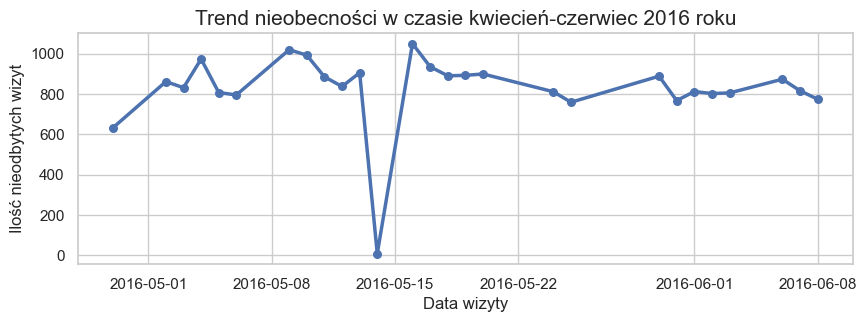

In [22]:
# 4: Wykres "Trend nieobecności w czasie kwiecień-czerwiec 2016 roku
# Ustawiamy wymiary wykresu
plt.figure(figsize=(10, 3))

# Grupowanie: liczymy ile osób nie przyszło danego dnia
daily_no_show = df_merged[df_merged["No-show"] == 1].groupby("AppointmentDay").size() # przez size liczymy ile pacjentów nie przyszło danego dnia

# Tworzymy wykres
sns.lineplot(x = daily_no_show.index , y = daily_no_show.values, linewidth=2.5)

plt.scatter(daily_no_show.index, daily_no_show.values, s=30) # s = 30 wielkość kropek na wykresie

# Dodajemy tytuł i opisy 
plt.title("Trend nieobecności w czasie kwiecień-czerwiec 2016 roku", fontsize = 15)
plt.xlabel("Data wizyty", fontsize = 12)
plt.ylabel("Ilość nieodbytych wizyt", fontsize = 12)

plt.show()


<h5 style="color: black;">Na wykresie zauważamy pewna anomalię, w okresie około 15 maja liczba nieobecności na wizytach jest bliska zeru, co znaczaco odbiega od wartości w innych datach. Sprawdźmy z czego to wynika::</h5>

In [23]:
# Sprawdzamy daty, w których liczba nieobecności była najniższa
print(daily_no_show.sort_values().head(3))

AppointmentDay
2016-05-14      9
2016-04-29    633
2016-05-25    759
dtype: int64


<h5 style="color: black;">Widzimy, że 14 maja nieobecności było tylko 9, sprawdźmy teraz czy wynika to  z faktu, iż 14 maja była sobota, a większość placówek medycznych w Brazylii nie pracuje w soboty i niedziele. </h5>


In [24]:
# Normalizujemy daty - zamieniamy np. 08:30 na 00:00 we wszystkich wierszach
df_merged['AppointmentDay'] = pd.to_datetime(df_merged['AppointmentDay']).dt.normalize()

# Musimy teraz odświeżyć nasze podliczenie nieobecności, żeby indeksy też były 'czyste'
daily_no_show = df_merged[df_merged['No-show'] == 1].groupby('AppointmentDay').size()

# Sprawdzamy teraz całkowita liczbę wizyt 14 maja i ilość nieobecności w tym dniu
szukana_data1 = pd.Timestamp('2016-05-14')
total_on_14_may = df_merged[df_merged['AppointmentDay'] == szukana_data1].shape[0]
no_shows_on_14_may = daily_no_show.get(szukana_data1, 0)

print(f"Całkowita liczba wizyt 14 maja: {total_on_14_may}")
print(f"Liczba nieobecności: {no_shows_on_14_may}")

Całkowita liczba wizyt 14 maja: 39
Liczba nieobecności: 9


<h5 style="color: black;">Rekordowo niska liczba nieobecności w dniu 14 maja wynika z faktu, że całkowita liczba zaplanowanych wizyt tego dnia była bardzo mała (jedynie 39), co jest charakterystyczne dla pracy placówek w weekendy. </h5>

<h4 style="color: navy; font-weight: bold;">Wniosek 4: </h4> <h5 style="color: navy;">Przez większość badanego okresu liczba nieobecności utrzymuje się na stablinym, wysokim poziomie, między 800-1000 wizyt dziennie, a gwałtowny spadek liczby nieobecności w dniu 14 maja nie wynika z nagłej poprawy dyscypliny pacjentów, lecz ze specyfiki pracy placówek.</h5>


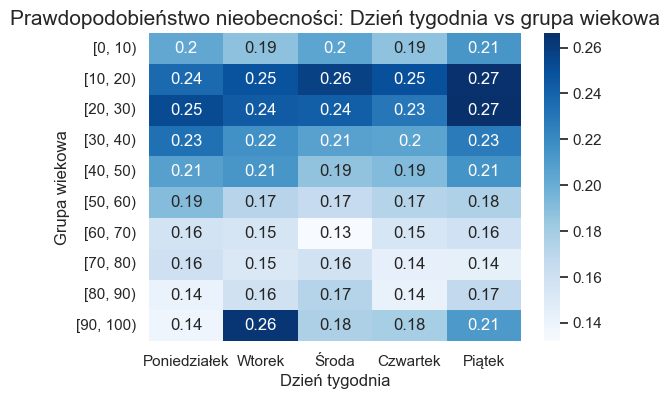

In [25]:
# 5: Wykres: "Prawdopodobieństwo nieobecności w trakcie tygodnia: Dzień tygodnia vs Grupa Wiekowa"
# Wycigamy dzień tygodnia z daty
df_merged["Day_of_week"] = df_merged["AppointmentDay"].dt.day_name()

# Słownik tłumaczeń
tlumacz_dni = {
    'Monday': 'Poniedziałek',
    'Tuesday': 'Wtorek',
    'Wednesday': 'Środa',
    'Thursday': 'Czwartek',
    'Friday': 'Piątek'
}

dni_pl = ['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 'Piątek']

df_merged['Day_of_week'] = df_merged['Day_of_week'].map(tlumacz_dni)

# Tworzymy tabelę przestawna
pivot_table = df_merged.pivot_table(index = "Age_Group",
                                    columns = "Day_of_week",
                                    values = "No-show",
                                    aggfunc = "mean",
                                    observed=False) # zapewnia wyświetlanie wszystkich grup, nawet tych bez danych
# Sortujemy kolumny według dni tygodnia
pivot_table = pivot_table[dni_pl]

# Tworzymy wykres
plt.figure(figsize=(6, 4))
sns.heatmap(data = pivot_table, annot = True, cmap = "Blues") # wpisujemy liczby do komórek w wykresie

# Dodajemy tytuł i opisy 
plt.title("Prawdopodobieństwo nieobecności: Dzień tygodnia vs grupa wiekowa", fontsize = 15)
plt.xlabel("Dzień tygodnia")
plt.ylabel("Grupa wiekowa")

plt.show()

<h4 style="color: navy; font-weight: bold;">Wniosek 5: </h4> <h5 style="color: navy;">Najbardziej problematycznym momentem w całym tygodniu sa piatki dla osób w wieku 10-30 lat.</h5>


<h3 style="color: navy; font-weight: bold;">4. Metody statystyczne :</h3>

<h4 style="color: navy; font-weight: bold;">1) Czy otrzymanie SMS-a przez pacjenta zwiększa szanse pojawienia się go na wizycie? </h4>

<h5 style="color: navy; font-weight: bold;">Hipoteza zerowa: SMS-y nie mają żadnego wpływu na to, czy pacjent przyjdzie. To, co widzimy w danych, to czysty przypadek. </h5>

##### Wykorzystamy tutaj Test Chi-kwadrat, by sprawdzić czy wpływ SMS-ów na obecność na wizycie to zasada czy czysty przypadek.


In [26]:
# Tworzymy tabelę krzyżową
contingency_table = pd.crosstab(df_merged['SMS_received'], df_merged['No-show'])

print("Tabela kontyngencji:")
print(contingency_table)
print("-" * 30)

# Wykonujemy test Chi-kwadrat
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Statystyka Chi-kwadrat: {chi2:.4f}")
print(f"Wartość p (p-value): {p_value:.10f}")
print("-" * 30)

# Interpretacja wyniku
if p_value < 0.05:
    print("Wniosek: Odrzucamy hipotezę zerową. Istnieje statystycznie istotna zależność między otrzymaniem SMS-a a obecnością na wizycie.")
else:
    print("Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej. SMS-y nie mają statystycznego wpływu na obecność.")

    

Tabela kontyngencji:
No-show           0      1
SMS_received              
0             62509  12535
1             25698   9784
------------------------------
Statystyka Chi-kwadrat: 1765.9758
Wartość p (p-value): 0.0000000000
------------------------------
Wniosek: Odrzucamy hipotezę zerową. Istnieje statystycznie istotna zależność między otrzymaniem SMS-a a obecnością na wizycie.


<h4 style="color: navy; font-weight: bold;">2) Czy występowanie opadów deszczu zwiększa liczbę nieobecności pacjentów na umówionych wizytach? </h4>

<h5 style="color: navy; font-weight: bold;">Hipoteza zerowa: Opady deszczu nie mają żadnego wpływu na to, czy pacjent przyjdzie. To, co widzimy w danych, to czysty przypadek. </h5>

##### Wykorzystamy tutaj test t-Studenta dla prób niezależnych, aby zweryfikować, czy różnica w średnim procencie nieobecności między dniami z opadami deszczu a dniami bezopadowymi jest istotna statystycznie

In [27]:
# Tworzymy nowa kolumne mówiaca o tym czy w danym dniu padało czy nie
df_merged['Is_Raining'] = (df_merged['Precipitation'] > 0).astype(int)

# Obliczamy średni % nieobecności na każdy dzień biorac pod uwagę czy danego dnia padało czy nie
daily_stats = df_merged.groupby(['AppointmentDay', 'Is_Raining'])['No-show'].mean().reset_index()

# Rozdzielamy dni na grupy do testu t-studenta
rainy_days_rates = daily_stats[daily_stats['Is_Raining'] == 1]['No-show']
sunny_days_rates = daily_stats[daily_stats['Is_Raining'] == 0]['No-show']

t_stat, p_val = stats.ttest_ind(rainy_days_rates, sunny_days_rates)

print(f"Średnia nieobecność w dni deszczowe: {rainy_days_rates.mean():.2%}")
print(f"Średnia nieobecność w dni słoneczne: {sunny_days_rates.mean():.2%}")
print("-" * 30)
print(f"Statystyka t: {t_stat:.4f}")
print(f"Wartość p (p-value): {p_val:.4f}")
print("-" * 30)
if p_val < 0.05:
    print("Wniosek: Odrzucamy hipotezę zerową. Występowanie opadów deszczu zwiększa liczbę nieobecności pacjentów na umówionych wizytach.")
else:
    print("Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej. Opady deszczu nie mają statystycznego wpływu na obecność.")



Średnia nieobecność w dni deszczowe: 20.18%
Średnia nieobecność w dni słoneczne: 20.50%
------------------------------
Statystyka t: -0.4426
Wartość p (p-value): 0.6619
------------------------------
Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej. Opady deszczu nie mają statystycznego wpływu na obecność.


<h4 style="color: navy; font-weight: bold;">3) Czy w okresie okołoświatecznym pacjenci częściej nie przychodza na wizyty?</h4>

<h5 style="color: navy; font-weight: bold;">Hipoteza zerowa: Okres okołoświateczny nie ma żadnego wpływu na to, czy pacjent przyjdzie. To, co widzimy w danych, to czysty przypadek. </h5>

##### Wybieramy tutaj test t-Studenta dla prób niezależnych, aby sprawdzić, czy różnica między średnim procentem nieobecności w dni okołoświąteczne a dni zwykłe jest istotna statystycznie.

In [28]:
# Zamieniamy listę napisów na format daty 
holidays_as_dates = pd.to_datetime(holidays_dates_2016).date

# Tworzymy "okno" +/- 1 dzień wokół świąt
holiday_window = []
for h_date in holidays_as_dates:
    for i in range(-1, 2): # Sprawdza: dzień przed (-1), w dniu (0), dzień po (1)
        holiday_window.append(h_date + timedelta(days=i))

# Oznaczamy w df_merged, czy wizyta była w "oknie świątecznym"

df_merged['Near_Holiday'] = df_merged['AppointmentDay'].dt.date.isin(holiday_window).astype(int)

# Agregujemy dane do poziomu dni (liczymy średni % nieobecności na dzień)
daily_holiday_stats = df_merged.groupby(['AppointmentDay', 'Near_Holiday'])['No-show'].mean().reset_index()

# Rozdzielamy na grupy i robimy test t-Studenta
h_group = daily_holiday_stats[daily_holiday_stats['Near_Holiday'] == 1]['No-show']
r_group = daily_holiday_stats[daily_holiday_stats['Near_Holiday'] == 0]['No-show']

t_stat, p_val = stats.ttest_ind(h_group, r_group)

print(f"Średnia nieobecność przy świętach: {h_group.mean():.2%}")
print(f"Średnia nieobecność w zwykłe dni: {r_group.mean():.2%}")
print(f"Wartość p (p-value): {p_val:.4f}")
print("-" * 30)

if p_val < 0.05:
    print("Wniosek: Odrzucamy hipotezę zerową. Okres okołoświateczny zwiększa liczbę nieobecności pacjentów na umówionych wizytach.")
else:
    print("Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej. Okres okołoświateczny nie ma statystycznego wpływu na obecność.")


Średnia nieobecność przy świętach: 19.77%
Średnia nieobecność w zwykłe dni: 20.39%
Wartość p (p-value): 0.5962
------------------------------
Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej. Okres okołoświateczny nie ma statystycznego wpływu na obecność.


<h4 style="color: navy; font-weight: bold;">4) Czy cukrzyca ma wpływ na obecność pacjenta na wizycie?</h4>

<h5 style="color: navy; font-weight: bold;">Hipoteza zerowa: Cukrzyca nie ma żadnego wpływu na to, czy pacjent przyjdzie. To, co widzimy w danych, to czysty przypadek. </h5>

##### Wykorzystamy tutaj Test Chi-kwadrat, by sprawdzić czy wpływ cukrzycy na obecność na wizycie to zasada czy czysty przypadek.


In [29]:
# Tworzymy tabelę krzyżową dla Cukrzycy i Nieobecności
diabetes_table = pd.crosstab(df_merged['Diabetes'], df_merged['No-show'])

# Wykonujemy test Chi-kwadrat
chi2, p_val, dof, expected = chi2_contingency(diabetes_table)

# Wyświetlamy procentowy udział (normalize='index' pokazuje % wierszami)
diabetes_pct = pd.crosstab(df_merged['Diabetes'], df_merged['No-show'], normalize='index')

print("Tabela kontyngencji (liczba osób):")
print(diabetes_table)
print("-" * 30)
print("Procentowy rozkład (0 = obecny, 1 = nieobecny):")
print(diabetes_pct)
print("-" * 30)
print(f"Wartość p (p-value): {p_val:.4f}")

if p_val < 0.05:
    print("Wniosek: Odrzucamy hipotezę zerową. Cukrzyca ma statystycznie istotny wpływ na obecność.")
else:
    print("Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej. Cukrzyca nie wpływa na frekwencję.")

Tabela kontyngencji (liczba osób):
No-show       0      1
Diabetes              
0         81694  20889
1          6513   1430
------------------------------
Procentowy rozkład (0 = obecny, 1 = nieobecny):
No-show          0         1
Diabetes                    
0         0.796370  0.203630
1         0.819967  0.180033
------------------------------
Wartość p (p-value): 0.0000
Wniosek: Odrzucamy hipotezę zerową. Cukrzyca ma statystycznie istotny wpływ na obecność.


<h4 style="color: navy; font-weight: bold;">5) Czy dzień tygodnia,w którym odbywa się wizyta ma wpływ na obecność pacjenta na wizycie?</h4>

<h5 style="color: navy; font-weight: bold;">Hipoteza zerowa: Dzień tygodnia nie ma znaczenia. Szansa na to, że pacjent nie przyjdzie, jest taka sama w poniedziałek, jak i w piątek.</h5>

##### Wykorzystamy tutaj test Chi-kwadrat, ponieważ porównujemy dwie zmienne kategoryczne: dzień tygodnia oraz status obecności.

In [30]:
# Wyciągamy nazwę dnia tygodnia z daty wizyty
df_merged['Day_of_Week'] = df_merged['AppointmentDay'].dt.day_name()

# Tworzymy tabelę krzyżową
weekday_table = pd.crosstab(df_merged['Day_of_Week'], df_merged['No-show'])

# Wykonujemy test Chi-kwadrat
chi2, p_val, dof, expected = chi2_contingency(weekday_table)

# Wyliczamy procenty dla lepszego wglądu (sortujemy, żeby było czytelnie)
weekday_pct = pd.crosstab(df_merged['Day_of_Week'], df_merged['No-show'], normalize='index')
weekday_pct = weekday_pct.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])

print("Procent nieobecności (1) w zależności od dnia tygodnia:")
print(weekday_pct[1].map('{:.2%}'.format))
print("-" * 30)
print(f"Wartość p (p-value): {p_val:.4f}")
print("-" * 30)

if p_val < 0.05:
    print("Wniosek: Odrzucamy hipotezę zerową. Dzień tygodnia ma statystycznie istotny wpływ na obecność.")
else:
    print("Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej. Brak dowodów na wpływ dnia tygodnia.")

Procent nieobecności (1) w zależności od dnia tygodnia:
Day_of_Week
Monday       20.65%
Tuesday      20.09%
Wednesday    19.69%
Thursday     19.35%
Friday       21.23%
Saturday     23.08%
Name: 1, dtype: object
------------------------------
Wartość p (p-value): 0.0000
------------------------------
Wniosek: Odrzucamy hipotezę zerową. Dzień tygodnia ma statystycznie istotny wpływ na obecność.


<h4 style="color: navy; font-weight: bold;">6) Czy wiek pacjenta wpływa na prawdopodobieństwo pojawienia się na wizycie?</h4>

<h5 style="color: navy; font-weight: bold;">Hipoteza zerowa: Wiek nie ma żadnego wpływu na frekwencję. Rozkład nieobecności jest taki sam we wszystkich grupach wiekowych.</h5>

##### Wykorzystamy tutaj podział na grupy wiekowe oraz test Chi-kwadrat, aby sprawdzić, czy przynależność do danej kategorii wiekowej wiąże się z inną dyscypliną pacjenta.

In [31]:
# Tworzymy przedziały wiekowe (binning)
# Podział: 0-12 (dzieci), 13-18 (nastolatki), 19-35 (młodzi dorośli), 36-60 (dorośli), 60+ (seniorzy)
bins = [0, 12, 18, 35, 60, 120]
labels = ['Dzieci', 'Nastolatki', 'Młodzi dorośli', 'Dorośli', 'Seniorzy']
df_merged['Age_Group'] = pd.cut(df_merged['Age'], bins=bins, labels=labels)

# Tworzymy tabelę krzyżową
age_table = pd.crosstab(df_merged['Age_Group'], df_merged['No-show'])

# Wykonujemy test Chi-kwadrat
chi2, p_val, dof, expected = chi2_contingency(age_table)

# Procentowy rozkład dla lepszej analizy
age_pct = pd.crosstab(df_merged['Age_Group'], df_merged['No-show'], normalize='index')

print("Procent nieobecności w grupach wiekowych:")
print(age_pct[1].map('{:.2%}'.format))
print("-" * 30)
print(f"Wartość p (p-value): {p_val:.4f}")
print("-" * 30)
if p_val < 0.05:
    print("Wniosek: Odrzucamy hipotezę zerową. Wiek ma bardzo istotny wpływ na obecność.")
else:
    print("Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej. Brak dowodów na wpływ wieku.")

Procent nieobecności w grupach wiekowych:
Age_Group
Dzieci            20.96%
Nastolatki        26.05%
Młodzi dorośli    23.83%
Dorośli           19.10%
Seniorzy          15.21%
Name: 1, dtype: object
------------------------------
Wartość p (p-value): 0.0000
------------------------------
Wniosek: Odrzucamy hipotezę zerową. Wiek ma bardzo istotny wpływ na obecność.


<h3 style="color: navy; font-weight: bold;">5. Las losowy :</h3>

In [47]:
# 1: PRZYGOTOWANIE DANYCH
# Liczymy czas oczekiwania pacjenta na wizytę
df_merged['Waiting_Time'] = (df_merged['AppointmentDay'] - df_merged['ScheduledDay']).dt.days
df_merged['Waiting_Time'] = df_merged['Waiting_Time'].clip(lower=0)

# Historia wizyt pacjenta - Sortujemy, aby poprawnie policzyć historię chronologicznie dla każdego pacjenta
df_merged = df_merged.sort_values(['PatientId', 'ScheduledDay'])

# Liczymy skumulowaną liczbę nieobecności przed bieżącą wizytą
df_merged['Prev_No_Shows'] = df_merged.groupby('PatientId')['No-show'].cumsum() - df_merged['No-show']

# Dzień tygodnia
df_merged['Day_of_Week'] = df_merged['AppointmentDay'].dt.day_name()

# 2: PRZYGOTOWANIE MODELU
# Wybieramy zestaw cech 
features = ['Age', 'SMS_received', 'Diabetes', 'Waiting_Time', 'Prev_No_Shows', 'Day_of_Week']
X = df_merged[features]
y = df_merged['No-show']

# Zamianiamy dni tygodnia na kolumny 0/1
X = pd.get_dummies(X, columns=['Day_of_Week'], drop_first=True)

# Dzielimy dane na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3: TRENOWANIE LASU LOSOWEGO (Random Forest)

# Używamy 100 drzew w naszym Lesie losowym
model_rf = RandomForestClassifier(n_estimators=100, 
                                  max_depth=15, 
                                  min_samples_split=10,
                                  random_state=42,
                                  class_weight='balanced'
                                 )
model_rf.fit(X_train, y_train)

# 4: WYNIKI

y_pred = model_rf.predict(X_test)

print(f"OSIĄGNIĘTA DOKŁADNOŚĆ MODELU: {accuracy_score(y_test, y_pred):.2%}")
print("\n------------------RAPORT KLASYFIKACJI------------------")
print(classification_report(y_test, y_pred))

# Wyświetlamy, co faktycznie pomogło modelowi
importances = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n----- RANKING WAŻNOŚCI CECH -----")
print(importances)

OSIĄGNIĘTA DOKŁADNOŚĆ MODELU: 65.35%

------------------RAPORT KLASYFIKACJI------------------
              precision    recall  f1-score   support

           0       0.88      0.65      0.75     17585
           1       0.33      0.67      0.44      4521

    accuracy                           0.65     22106
   macro avg       0.61      0.66      0.60     22106
weighted avg       0.77      0.65      0.69     22106


----- RANKING WAŻNOŚCI CECH -----
Waiting_Time             0.577829
Age                      0.286564
Prev_No_Shows            0.060769
SMS_received             0.037559
Diabetes                 0.009269
Day_of_Week_Monday       0.007560
Day_of_Week_Tuesday      0.007136
Day_of_Week_Thursday     0.006546
Day_of_Week_Wednesday    0.006269
Day_of_Week_Saturday     0.000499
dtype: float64


<h3 style="color: navy; font-weight: bold;">Podsumowanie lasu losowego:</h3>

<h5 style="color: navy;">1) Dokładność naszego modelu wynosi 65,35%. Nie jest to wynik idealny pod względem czystej statystyki, lecz dzięki zbalansowaniu danych algorytm przestał ignorować mniejszą grupę pacjentów. Stał się tym samym znacznie bardziej użyteczny niż model o 80-procentowej dokładności, ponieważ potrafi on teraz wykryć aż 67% faktycznych nieobecności.</h5>
<h5 style="color: navy;">2) Zmienna czasu oczekiwania na wizytę odpowiada za 58% decyzji modelu. Potwierdza to trend: im dłużej pacjent musi czekać na termin, tym bardziej prawdopodobne jest, że na nim się nie pojawi.</h5>
<h5 style="color: navy;">3) Wiek (28%) oraz historia wcześniejszych nieobecności (6%) to kolejne kluczowe filary, na których model opiera swoje przewidywania. Potwierdza to, że zachowania pacjentów są przewidywalne i często zależą od ich etapu życia oraz wcześniejszych nawyków.</h5>